# Network Science Assignment 5

Author:  
Elias Müller   
18-615-658

Submission Date:  
Monday, 28. October 2024

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import glob

In [2]:
data_paths = glob.glob("data/*.gml")
data_names = [str(x.replace("data/graph_", "")).replace(".gml", "") for x in data_paths]
data_lst = list(map(nx.read_gml, data_paths))

## Task 1

For the provided network datasets find the communities using (a) the greedy modularity maximization by Clauset Newman and Moore and (b) the label propagation algorithm.
Assign to each community a color and draw the resulting graph, where each node is colored after the community it belongs to, while community internal links and inter‑communities links are clearly recognizable.


In [20]:
def greedy_modularity_maximization(G): 
    communities = nx.community.greedy_modularity_communities(G)
    return communities


def label_propagation(G):
    communities = nx.community.label_propagation_communities(G)
    return communities

In [21]:
#visualization
def initialize_visualization(ROWS, COLS): 
    fig, axes = plt.subplots(ROWS, COLS, figsize=(8 * COLS, 8 * ROWS), dpi=300)
    return fig, axes

In [32]:
def community_figure(ROWS, COLS, data, title):
    fig, axes = initialize_visualization(ROWS, COLS)
    for i, G in enumerate(data):
        communities = [list(greedy_modularity_maximization(G)), list(label_propagation(G))]
        color_map = {}

        for r in range(len(communities)):
            # Define colors for communities
            for ii, community in enumerate(communities[r]):
                color = plt.cm.tab20(ii)
                for node in community:
                    color_map[node] = color

            # Draw graph
            pos = nx.spring_layout(G)
            nx.draw(G, 
                    pos, 
                    node_color=[color_map[node] for node in G.nodes()],
                    node_size=50, 
                    edgelist=G.edges(),
                    width=0.5,
                    edge_color=['black' if any(edge[0] in community and edge[1] in community for community in communities[r]) else 'lightgray' for edge in G.edges()],
                    ax=axes[i][r])
            
            # Calculate modularity and add text
            modularity_score = nx.algorithms.community.quality.modularity(G, communities[r])
            axes[i][r].text(0.05, 0.95, f"Modularity: {modularity_score:.3f}", 
                            transform=axes[i][r].transAxes, fontsize=12,
                            verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

            # Title for each subplot
            algo_name = "Greedy Modularity Maximization" if r == 0 else "Label Propagation"
            axes[i][r].set_title(f"{data_names[i]} - {algo_name}", fontsize=16)
            axes[i][r].axis('off')

        # Set main title
        fig.suptitle(title, fontsize=20, y=0.92)
        
    return communities[0], communities[1]


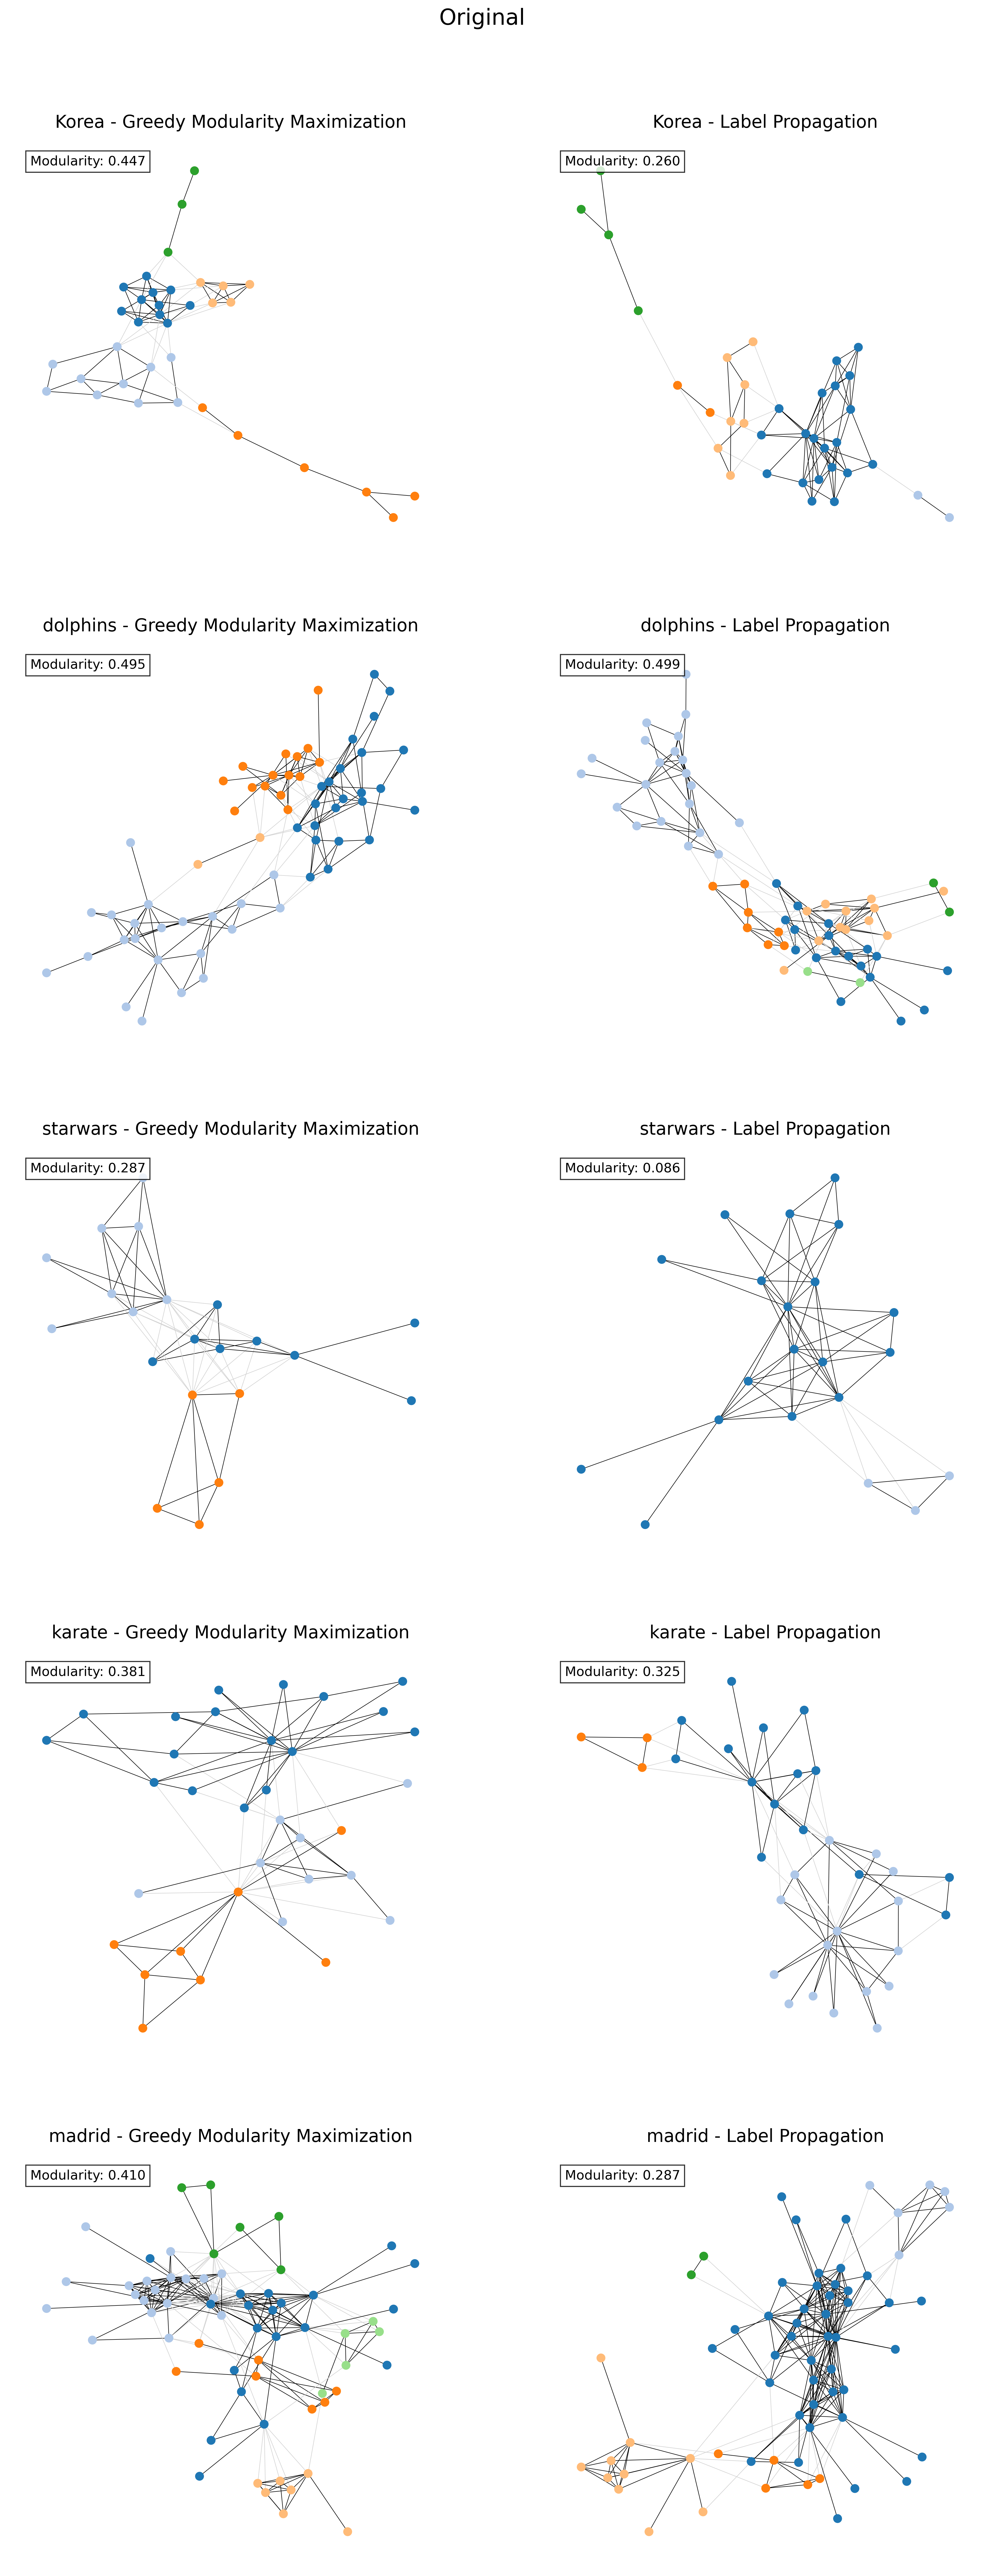

In [33]:
# a) greedy_modularity_maximization
communities_GMM, communities_LP= community_figure(5,2, data_lst, "Original")

## Task 2
Randomise each network and repeat the exercise at task 1.

In [8]:
# we perform degree preserving randomization of the data
data_lst_R = [nx.algorithms.smallworld.random_reference(G, connectivity=True) for G in data_lst]

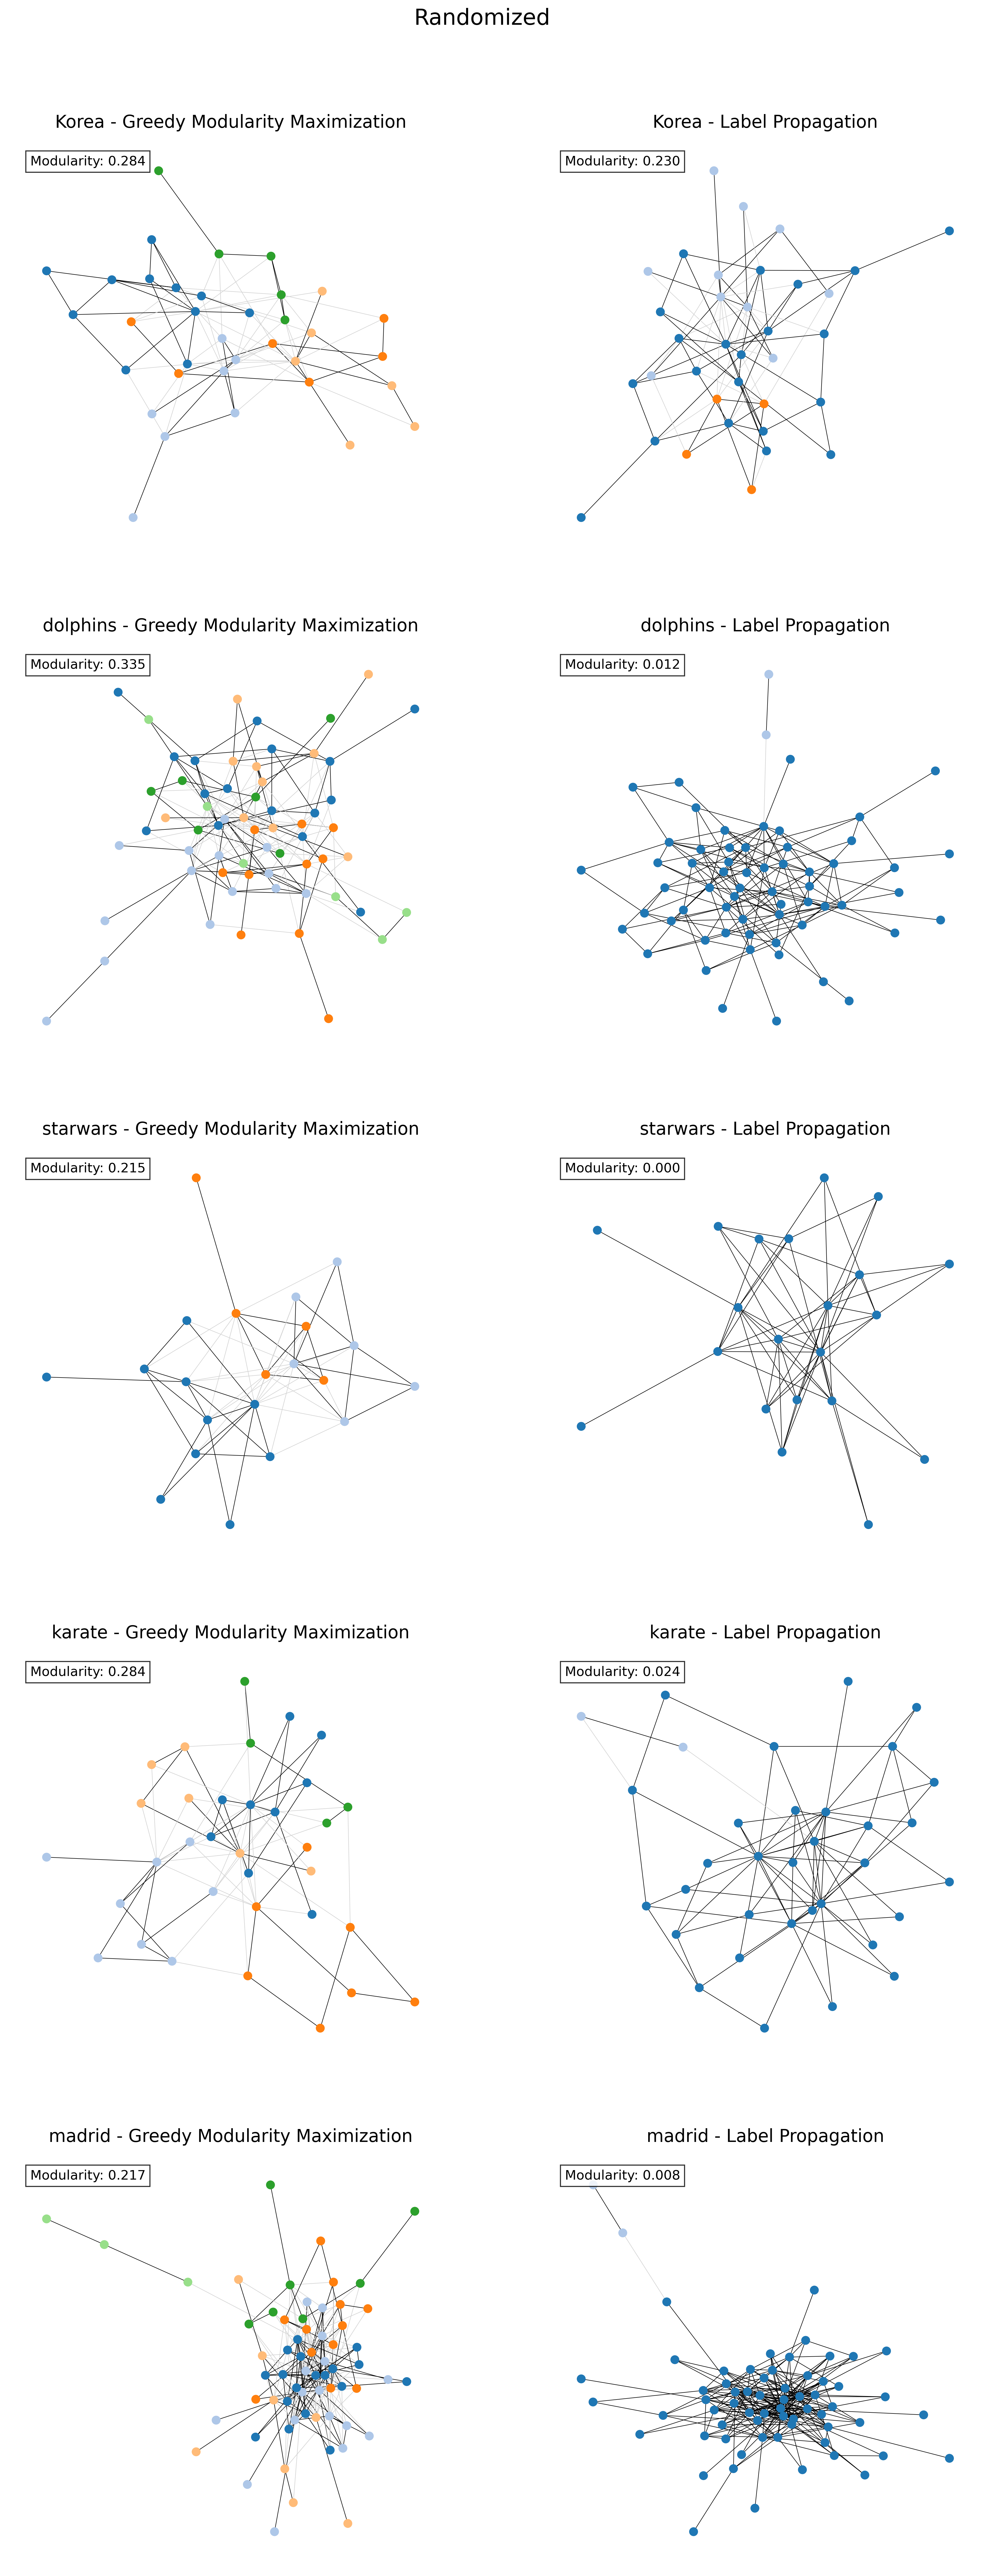

In [35]:
# 2a) greedy_modularity_maximization randomized
communities_GMM_R, communities_LP_R = community_figure(5,2, data_lst_R, "Randomized")

In [36]:
print(f"Greedy Modularity Maximization: {len(communities_GMM)} Communities with {[str(len(C)) for C in communities_GMM]}")
print(f"Greedy Modularity Maximization Randomized: {len(communities_GMM_R)} Communities with {[str(len(C)) for C in communities_GMM_R]}")
print(f"Label Propagation: {len(communities_LP)} Communities with {[str(len(C)) for C in communities_LP]}")
print(f"Label Propagation Randomized: {len(communities_LP_R)} Communities with {[str(len(C)) for C in communities_LP_R]}")


Greedy Modularity Maximization: 6 Communities with ['20', '19', '7', '7', '6', '5']
Greedy Modularity Maximization Randomized: 6 Communities with ['18', '16', '12', '8', '7', '3']
Label Propagation: 5 Communities with ['41', '6', '5', '10', '2']
Label Propagation Randomized: 2 Communities with ['62', '2']


### Interpretation
Compare the number of communities obtained before and after randomisation and the quality of community detection before and after randomisation.